## Påverkan av klimat, läckage och infiltrationsanläggning
*Del 3: Tillägg av infiltrationsmodell och scenarioanalys*

Denna notebook utgår från den sparade modellen med klimat + läckage och lägger till infiltration.

Steg:
1. Importera bibliotek
2. Ladda in modell med läckage
3. Ladda och bearbeta infiltrationsdata
4. Lägg till infiltrationsmodell och kalibrera
5. Visa slutresultat och scenarioanalys

### 0. Importera bibliotek

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pastas as ps
from matplotlib.patches import Rectangle

ps.set_log_level("ERROR")

### 1. Ladda in modell med läckage

In [2]:
WELL_NAME = "17U"
model_path_in = "../data/obj_17U_m2.pas"


ml_3 = getattr(ps, "io").load(model_path_in)
ml_3.name = f"{WELL_NAME}_m3"

tmin = "2017-07-01"
tmax = "2021-04-01"

print(f"Inläst modell: {ml_3.name}")
print(f"Stressmodeller före tillägg: {list(ml_3.stressmodels.keys())}")

Inläst modell: 17U_m3
Stressmodeller före tillägg: ['recharge', 'leakage']


### 2. Ladda och bearbeta infiltrationsdata

In [5]:
data_mapp = "../data"

infi = pd.read_csv(
    os.path.join(data_mapp, "inf_tunnel_gbg.csv"),
    sep=";",
    encoding="ISO-8859-1",
    usecols=["Benämning", "Tidpunkt", "Värde"]
)

def build_infiltration(code):
    return (
        infi.loc[infi["Benämning"] == code]
        .assign(Tidpunkt=lambda d: pd.to_datetime(d["Tidpunkt"], errors="coerce"))
        .dropna(subset=["Tidpunkt"])
        .set_index("Tidpunkt")["Värde"]
        .mul(1.44)
        .groupby(pd.Grouper(freq="D"))
        .mean()
        .round(1)
        .replace(0, np.nan)
        .interpolate("linear")
        .fillna(0)
        .loc[lambda s: s.ne(0)]
        .rename(code)
    )

infiltration_U = build_infiltration("1BINF")
infiltration_B = build_infiltration("2HINF")
I_stresses = [infiltration_U, infiltration_B]

distanceinfiltration = (
    pd.read_csv(
        os.path.join(data_mapp, "inf_dist_tunnel_gbg.csv"),
        sep=";",
        index_col="distance"
    )
    .sort_index()
    .loc["1BINF":"2HINF", WELL_NAME]
    .astype(int)
    .tolist()
)

print(f"Antal infiltrationsserier: {len(I_stresses)}")
print(f"Avstånd infiltration (m): {distanceinfiltration}")

Antal infiltrationsserier: 2
Avstånd infiltration (m): [314, 219]


### 3. Lägg till infiltrationsmodell och kalibrera

<Axes: ylabel='Head'>

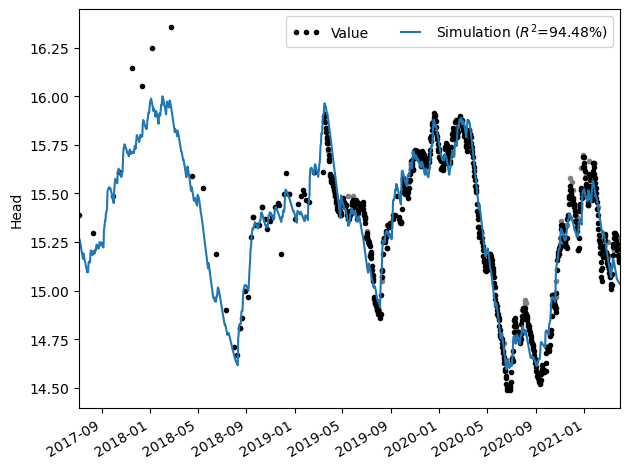

In [6]:

ml_3.add_stressmodel(
    ps.WellModel(
        stress=I_stresses,
        rfunc=ps.HantushWellModel(),
        name="infiltration",
        distances=distanceinfiltration,
        up=True,
    )
)

ml_3.solve(
    report=False,
    solver=ps.LmfitSolve(),
    tmin=tmin,
    tmax=tmax,
)

ml_3.plot()

### 4. Visa slutresultat och scenarioanalys

Aktiva stressmodeller: ['recharge', 'leakage', 'infiltration']


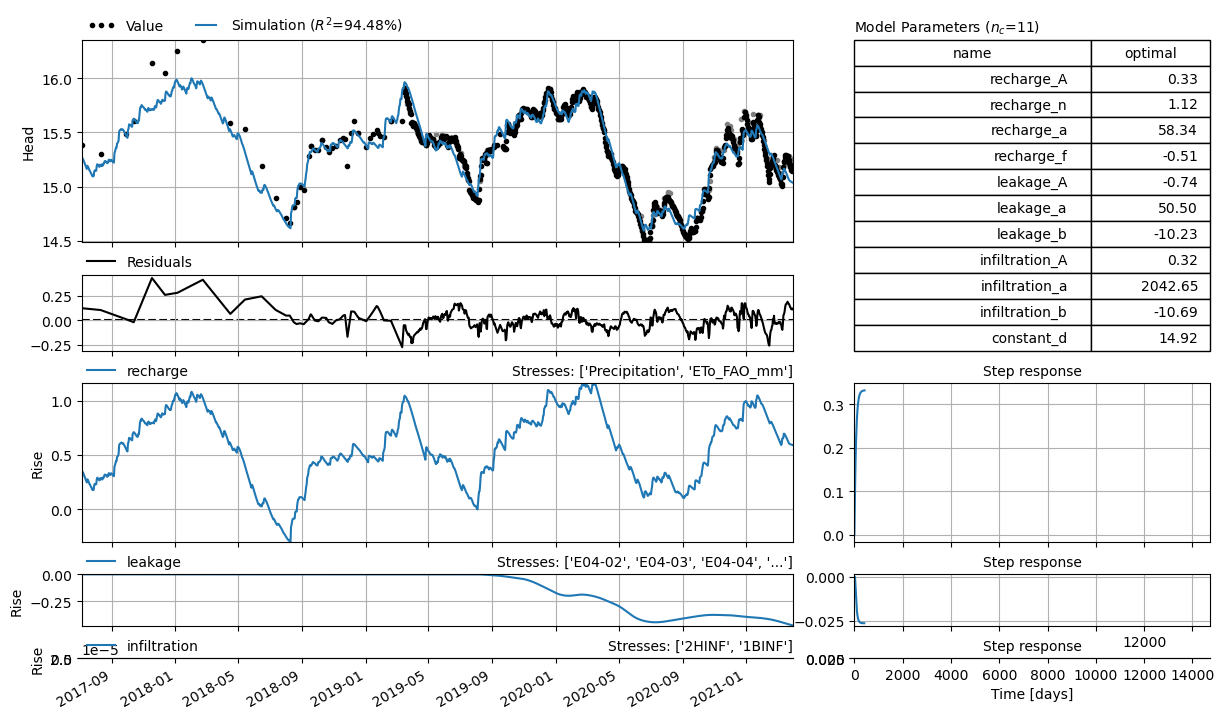

In [7]:
ml_3.plots.results(figsize=(12, 7))

print(f"Aktiva stressmodeller: {list(ml_3.stressmodels.keys())}")

Infiltration har ingen påverkan.